# Análisis Exploratorio de Datos (EDA) - Predicción de Adopción de Mascotas

# Introducción
 
El objetivo de este notebook es realizar un análisis exploratorio sobre el conjunto de datos de PetFinder. Buscamos entender las características de las mascotas, cómo se relacionan entre sí y, lo más importante, qué factores influyen en la velocidad de adopción (`AdoptionSpeed`).
 
Para este análisis, utilizaremos los siguientes archivos:
* `train.csv`: El conjunto de datos principal con información de cada mascota.
* `breed_labels.csv`: Mapeo de los IDs de razas a sus nombres.
* `color_labels.csv`: Mapeo de los IDs de colores a sus nombres.
* `state_labels.csv`: Mapeo de los IDs de estados a sus nombres.

# 1. Carga de Librerías y Datos

Primero, importamos las librerías necesarias para el análisis y la visualización.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

BASE_PATH = r"C:\Users\molin\OneDrive\Desktop\Maestria_Ciencia_de_Datos\Labo_2\petfinder-adoption-prediction"

try:
    train_df = pd.read_csv(os.path.join(BASE_PATH, "train", "train.csv"))
    breed_df = pd.read_csv(os.path.join(BASE_PATH, "breed_labels.csv"))
    color_df = pd.read_csv(os.path.join(BASE_PATH, "color_labels.csv"))
    state_df = pd.read_csv(os.path.join(BASE_PATH, "state_labels.csv"))
    
    print("Archivos cargados exitosamente.")
    
except FileNotFoundError as e:
    print(f"Error: No se pudo encontrar el archivo en la ruta especificada.")
    print(f"Detalle del error: {e}")
    print("\nPor favor, asegúrate de que la variable 'BASE_PATH' esté configurada correctamente.")

Archivos cargados exitosamente.


# 2. Vistazo Inicial a los Datos


In [ ]:
print("\n--- Información General del DataFrame 'train' ---")
train_df.info()

print("\n--- Primeras 5 filas del DataFrame 'train' ---")
print(train_df.head())

print("\n--- Resumen Estadístico de las Columnas Numéricas ---")
print(train_df.describe())


--- Información General del DataFrame 'train' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17 

: 

: 

: 

: 

# 3. Fusión de Datos para un Análisis más Claro

Para hacer el análisis más intuitivo, vamos a reemplazar los IDs de raza, color y estado por sus nombres correspondientes.

In [ ]:
# --- Cruce con Estados ---
train_df = train_df.merge(state_df, left_on='State', right_on='StateID', how='left')
train_df.drop(['State', 'StateID'], axis=1, inplace=True) # Eliminamos las columnas de ID
train_df.rename(columns={'StateName': 'State'}, inplace=True)

# --- Cruce con Razas ---
# Raza 1
train_df = train_df.merge(breed_df, left_on='Breed1', right_on='BreedID', how='left')
train_df.drop(['Breed1', 'BreedID'], axis=1, inplace=True)
train_df.rename(columns={'BreedName': 'Breed1'}, inplace=True)

# Raza 2 (muchas mascotas no tienen una segunda raza, por lo que los nulos son esperados)
train_df = train_df.merge(breed_df, left_on='Breed2', right_on='BreedID', how='left', suffixes=('_r1', '_r2'))
train_df.drop(['Breed2', 'BreedID'], axis=1, inplace=True)
train_df.rename(columns={'BreedName': 'Breed2'}, inplace=True)

# --- Cruce con Colores ---
# Color 1
train_df = train_df.merge(color_df, left_on='Color1', right_on='ColorID', how='left')
train_df.drop(['Color1', 'ColorID'], axis=1, inplace=True)
train_df.rename(columns={'ColorName': 'Color1'}, inplace=True)

# Color 2
train_df = train_df.merge(color_df, left_on='Color2', right_on='ColorID', how='left', suffixes=('_c1', '_c2'))
train_df.drop(['Color2', 'ColorID'], axis=1, inplace=True)
train_df.rename(columns={'ColorName': 'Color2'}, inplace=True)

# Color 3
train_df = train_df.merge(color_df, left_on='Color3', right_on='ColorID', how='left', suffixes=('_c1_c2', '_c3'))
train_df.drop(['Color3', 'ColorID'], axis=1, inplace=True)
train_df.rename(columns={'ColorName': 'Color3'}, inplace=True)


print("\n--- Primeras 5 filas del DataFrame fusionado ---")
print(train_df.head())


--- Primeras 5 filas del DataFrame fusionado ---
   Type_x         Name  Age  Gender  MaturitySize  FurLength  Vaccinated  \
0       2       Nibble    3       1             1          1           2   
1       2  No Name Yet    1       1             2          2           3   
2       1       Brisco    1       1             2          2           1   
3       1         Miko    4       2             2          1           1   
4       1       Hunter    1       1             2          1           2   

   Dewormed  Sterilized  Health  ...  PhotoAmt  AdoptionSpeed         State  \
0         2           2       1  ...       1.0              2      Selangor   
1         3           3       1  ...       2.0              0  Kuala Lumpur   
2         1           2       1  ...       7.0              3      Selangor   
3         1           2       1  ...       8.0              2  Kuala Lumpur   
4         2           2       1  ...       3.0              2      Selangor   

   Type_y         

: 

: 

: 

: 

# 4. Análisis de la Variable Objetivo: `AdoptionSpeed`

La variable `AdoptionSpeed` indica cuán rápido fue adoptada una mascota. Sus valores significan:
* 0: Adoptado el mismo día.
* 1: Adoptado entre 1 y 7 días.
* 2: Adoptado entre 8 y 30 días.
* 3: Adoptado entre 31 y 90 días.
* 4: No adoptado después de 100 días.

Análisis: Se observa que la mayoría de las mascotas no son adoptadas rápidamente. La categoría "No adoptado después de 100 días" (4) es la más común, seguida de adopciones en el primer mes (2). Las adopciones el mismo día (0) son las menos frecuentes.

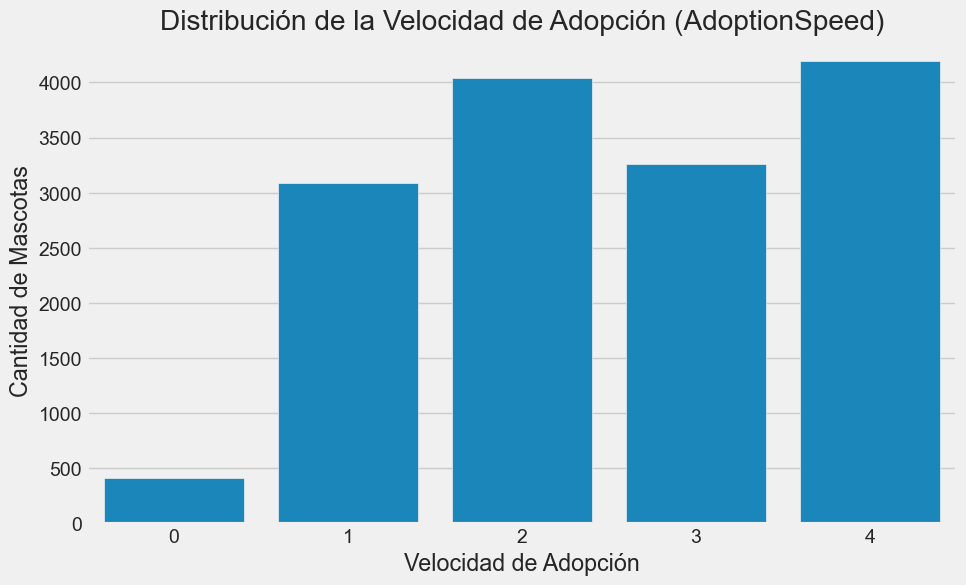

: 

: 

: 

: 

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='AdoptionSpeed', data=train_df)
plt.title('Distribución de la Velocidad de Adopción (AdoptionSpeed)')
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Cantidad de Mascotas')
plt.show()

# 5. Análisis de Cruces con Variables Categóricas

Analicemos cómo algunas variables categóricas se relacionan con la velocidad de adopción.

Tipo de Animal (Perro vs. Gato):Los perros y gatos tienen distribuciones de `AdoptionSpeed` relativamente similares, aunque parece haber una proporción ligeramente mayor de gatos en la categoría de adopción más lenta (4).

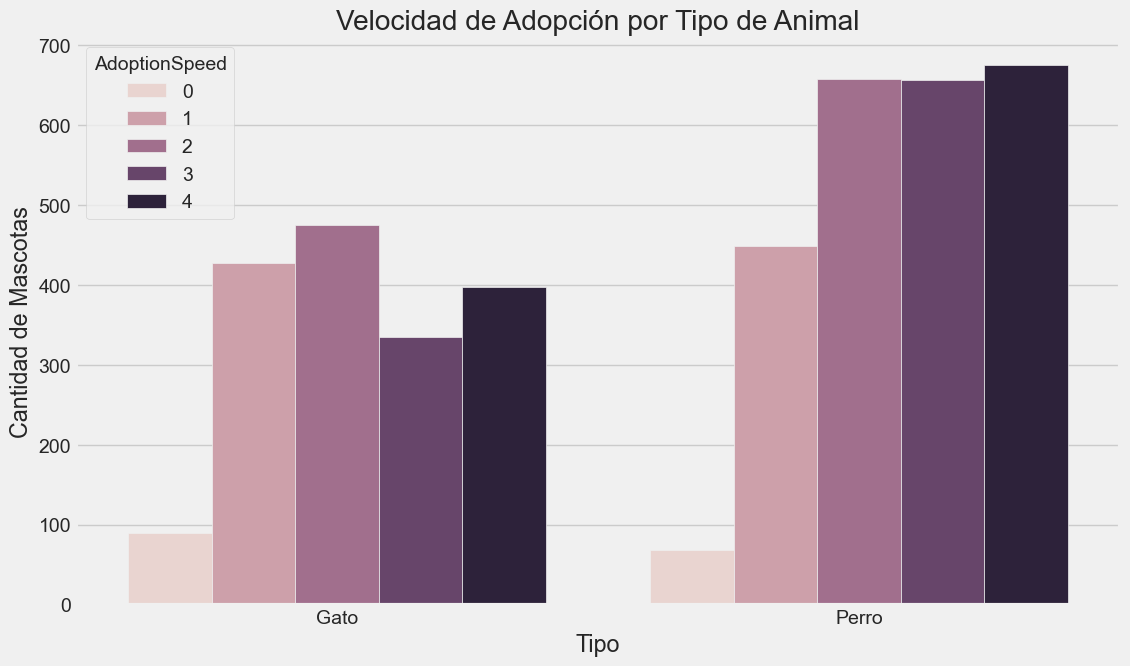

: 

: 

: 

: 

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Type', hue='AdoptionSpeed', data=train_df.replace({'Type': {1: 'Perro', 2: 'Gato'}}))
plt.title('Velocidad de Adopción por Tipo de Animal')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de Mascotas')
plt.show()

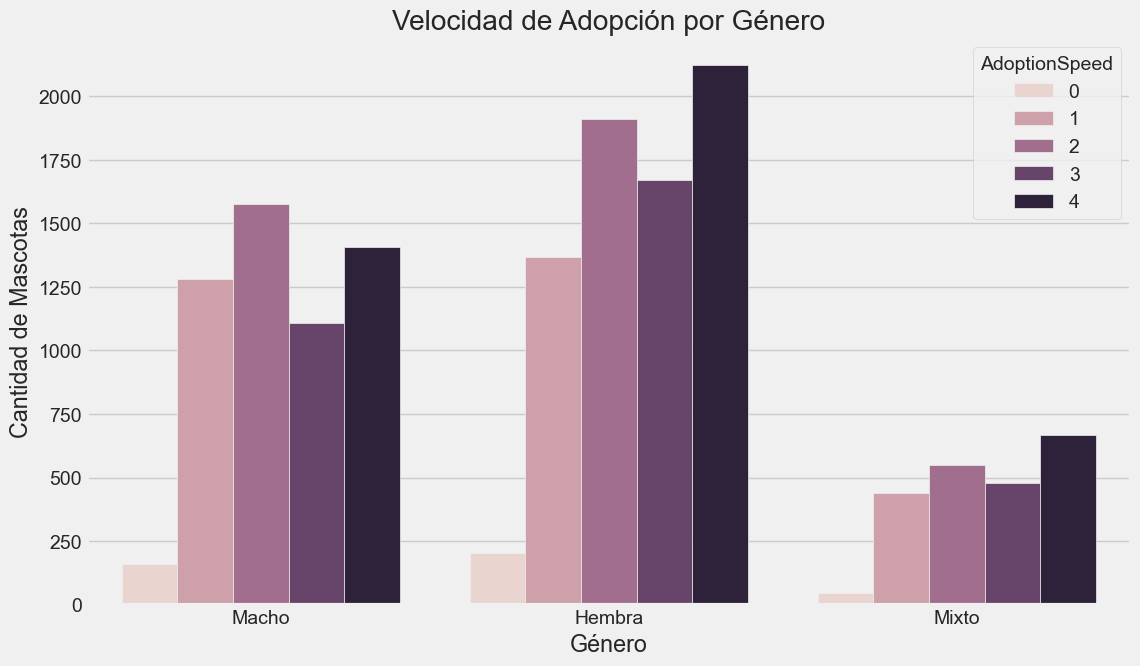

: 

: 

: 

: 

In [ ]:
# --- Género ---
plt.figure(figsize=(12, 7))
sns.countplot(x='Gender', hue='AdoptionSpeed', data=train_df.replace({'Gender': {1: 'Macho', 2: 'Hembra', 3: 'Mixto'}}))
plt.title('Velocidad de Adopción por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Mascotas')
plt.show()

No parece haber una diferencia drástica entre machos y hembras. Los grupos mixtos son muy pequeños para sacar conclusiones.

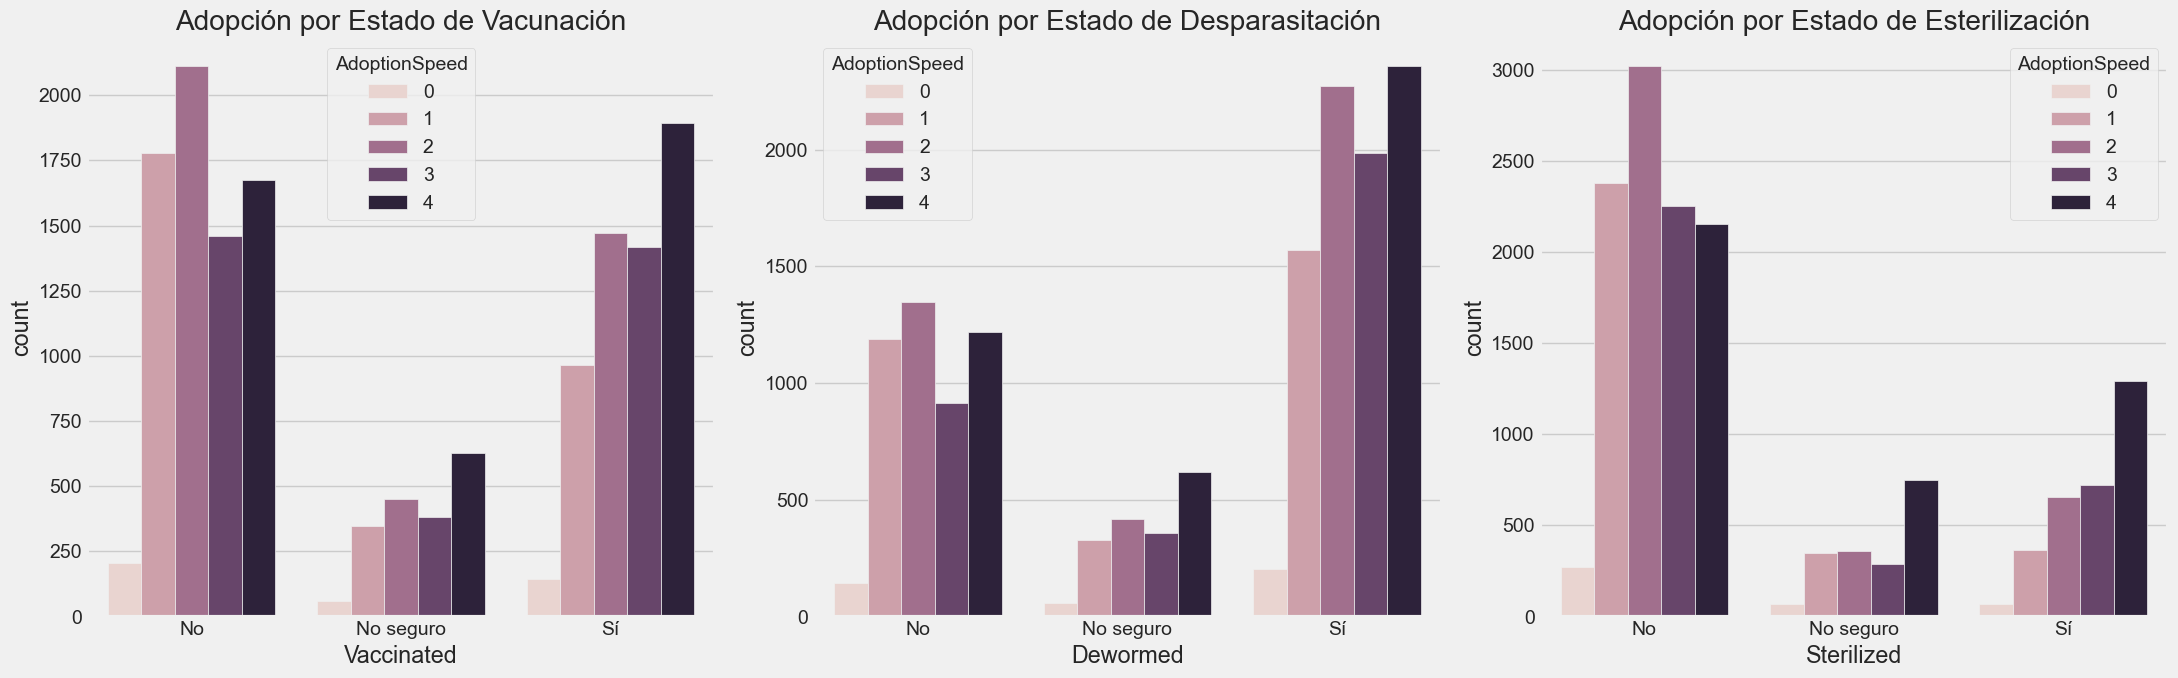

: 

: 

: 

: 

In [ ]:
# --- Estado de Salud (Vacunado, Desparasitado, Esterilizado) ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
sns.countplot(x='Vaccinated', hue='AdoptionSpeed', data=train_df.replace({'Vaccinated': {1: 'Sí', 2: 'No', 3: 'No seguro'}}), ax=axes[0]).set_title('Adopción por Estado de Vacunación')
sns.countplot(x='Dewormed', hue='AdoptionSpeed', data=train_df.replace({'Dewormed': {1: 'Sí', 2: 'No', 3: 'No seguro'}}), ax=axes[1]).set_title('Adopción por Estado de Desparasitación')
sns.countplot(x='Sterilized', hue='AdoptionSpeed', data=train_df.replace({'Sterilized': {1: 'Sí', 2: 'No', 3: 'No seguro'}}), ax=axes[2]).set_title('Adopción por Estado de Esterilización')
fig.tight_layout()
plt.show()

Las mascotas que están vacunadas, desparasitadas y, especialmente, esterilizadas, tienden a tener una proporción mayor en las categorías de adopción más rápidas (0, 1, 2) en comparación con las que no lo están. La esterilización parece ser un factor particularmente influyente.

# 6. Análisis de Cruces con Variables Numéricas

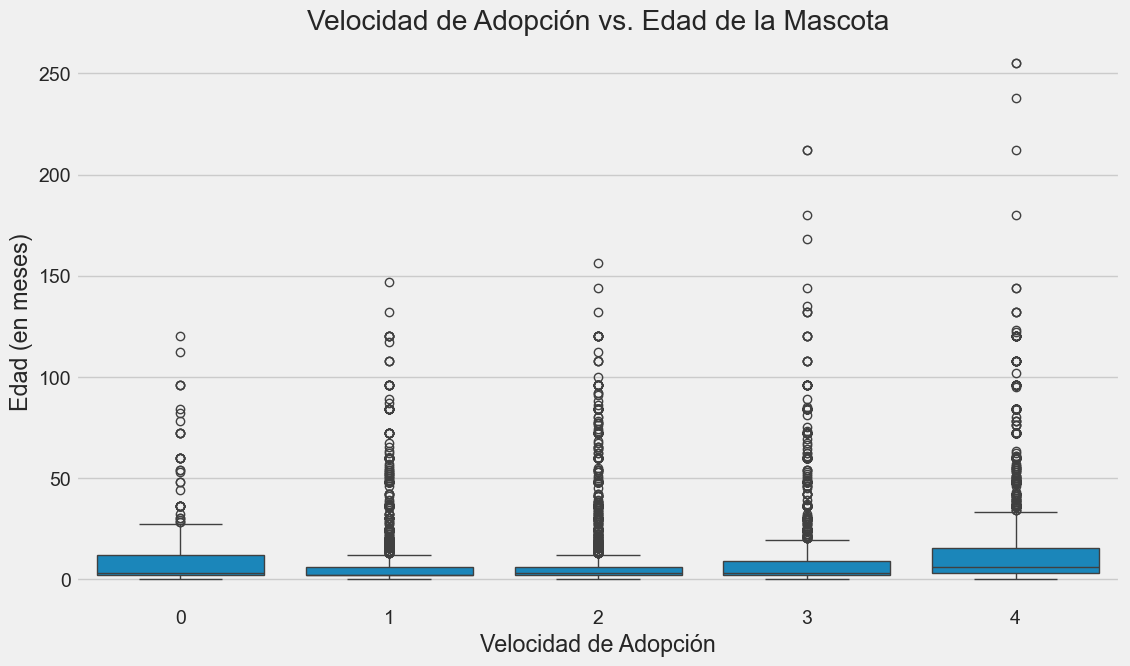

: 

: 

In [ ]:
# --- Edad (`Age`) ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='AdoptionSpeed', y='Age', data=train_df)
plt.title('Velocidad de Adopción vs. Edad de la Mascota')
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Edad (en meses)')
plt.show()

Análisis: Este es uno de los gráficos más reveladores. Hay una correlación muy fuerte y positiva entre la edad y el tiempo que tarda una mascota en ser adoptada. Los cachorros (edad cercana a 0) son adoptados mucho más rápido. A medida que la edad aumenta, la velocidad de adopción disminuye drásticamente.

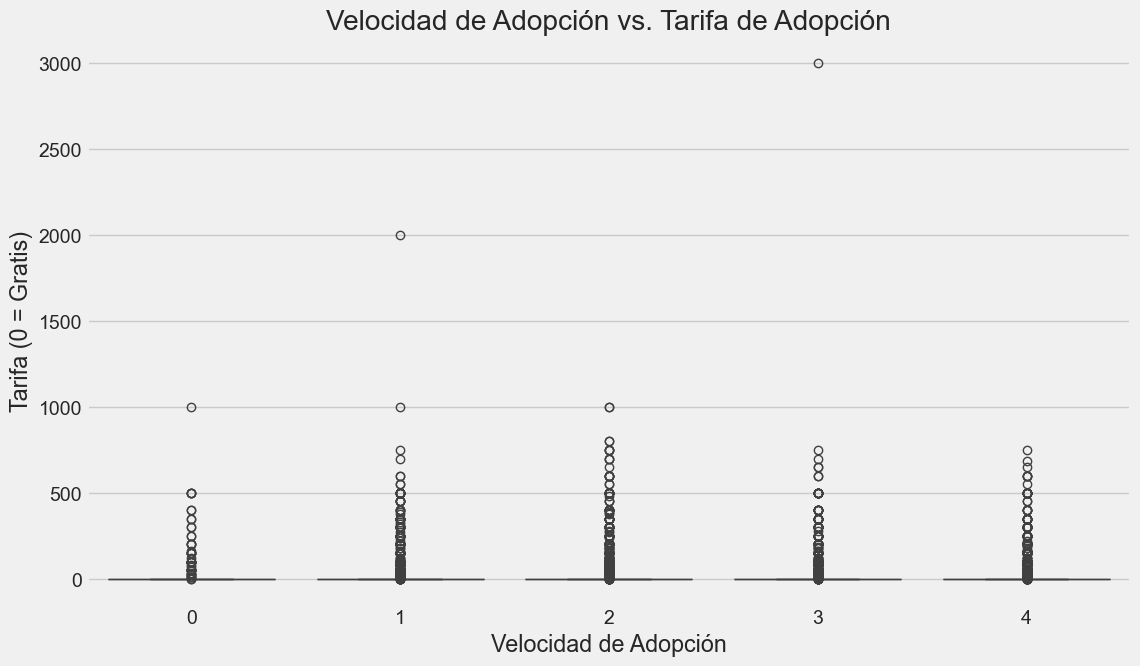

: 

: 

: 

: 

: 

In [ ]:
# --- Tarifa (`Fee`) ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='AdoptionSpeed', y='Fee', data=train_df)
plt.title('Velocidad de Adopción vs. Tarifa de Adopción')
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Tarifa (0 = Gratis)')
plt.show()

Las mascotas con tarifa cero (`Fee` = 0) se encuentran en todas las categorías de adopción, pero dominan en las más lentas (3 y 4). Esto podría ser contraintuitivo, pero podría indicar que una tarifa (incluso pequeña) se asocia con mascotas de razas más deseables o que ya están preparadas (vacunadas/esterilizadas), lo que acelera su adopción.

# 7. Análisis de Cruces con Raza, Color y Estado

Top 10 Razas más comunes y su velocidad de adopción

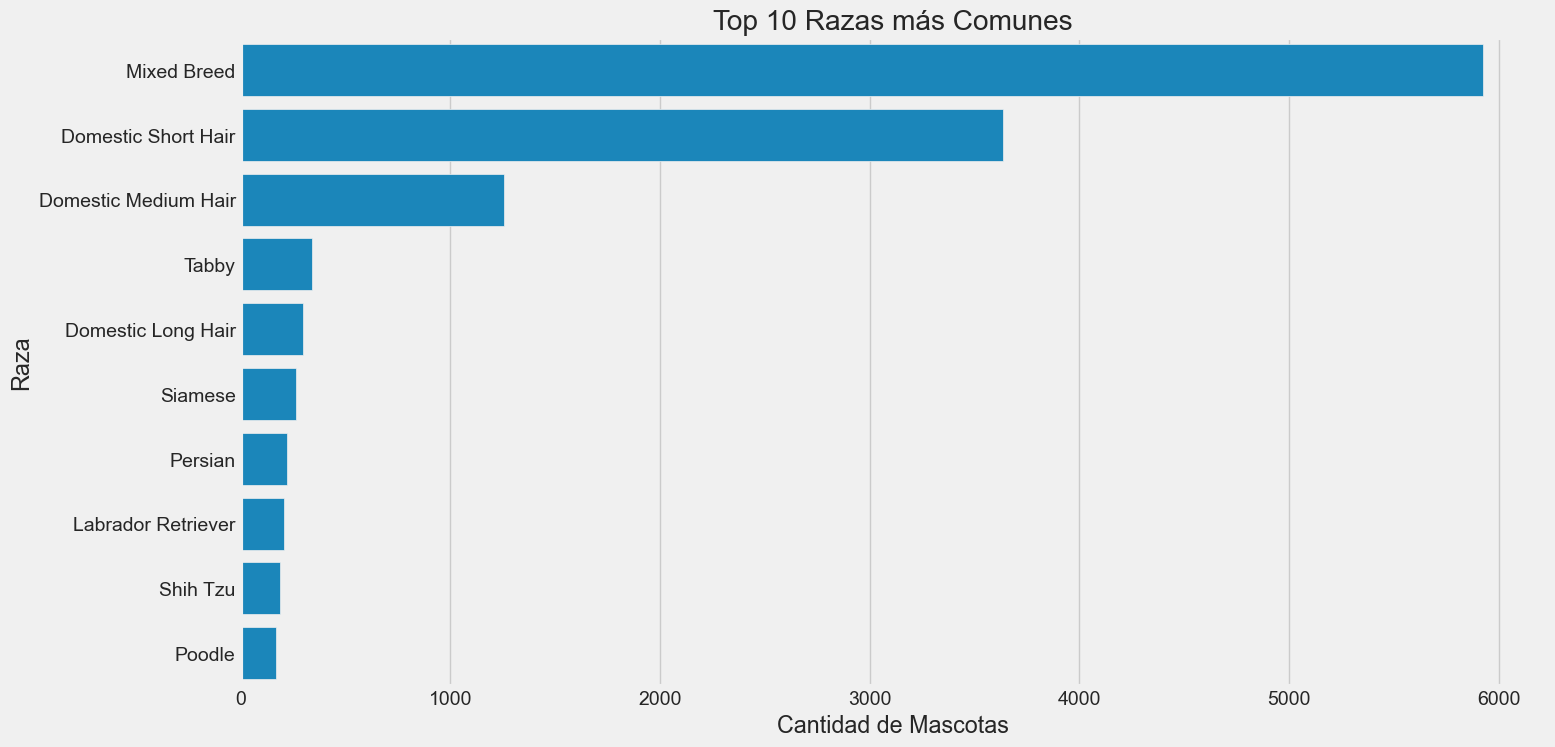

: 

: 

: 

: 

In [ ]:
top_breeds = train_df['Breed1'].value_counts().nlargest(10).index
plt.figure(figsize=(15, 8))
sns.countplot(y='Breed1', data=train_df[train_df['Breed1'].isin(top_breeds)], order=top_breeds)
plt.title('Top 10 Razas más Comunes')
plt.xlabel('Cantidad de Mascotas')
plt.ylabel('Raza')
plt.show()

La raza "Domestic Short Hair" (gato común) y "Mixed Breed" (perro mestizo) son, con diferencia, las más frecuentes en el conjunto de datos.

Top 10 Colores más comunes

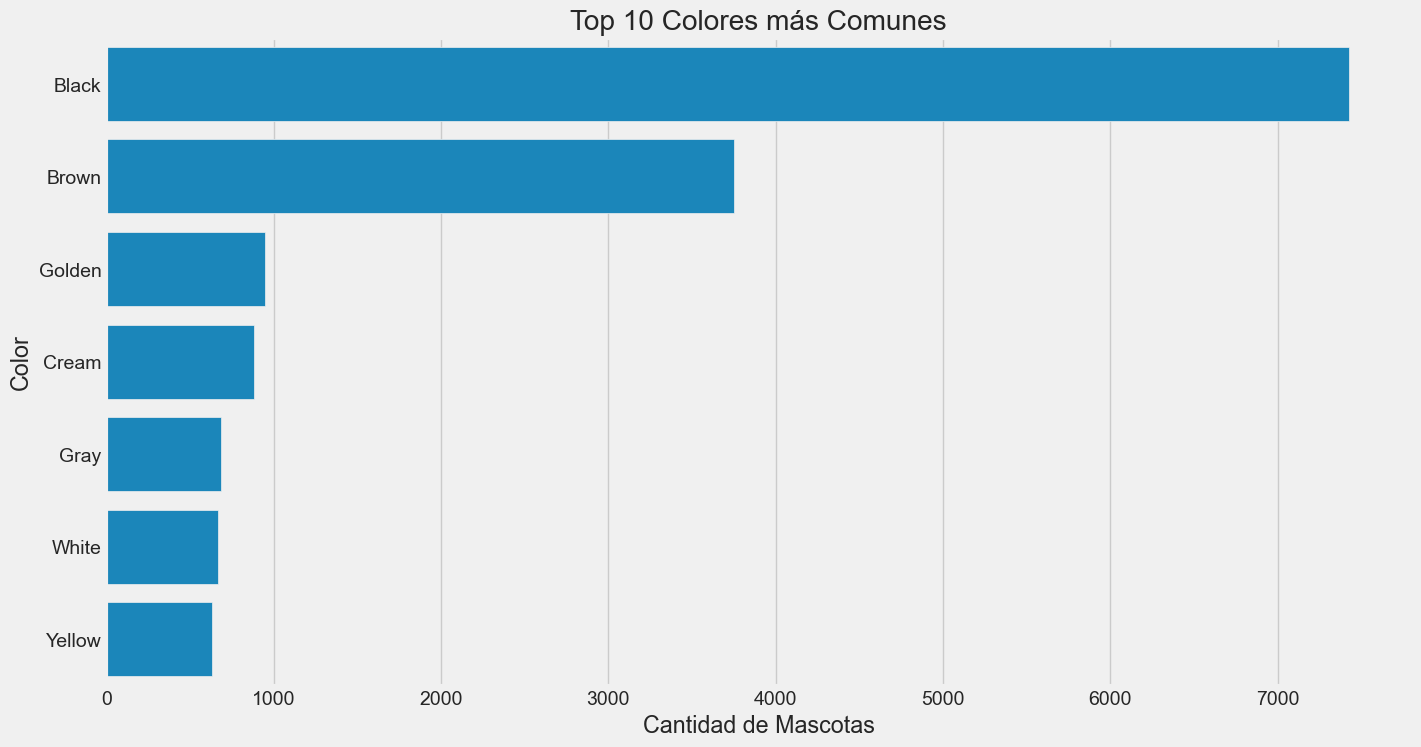

: 

: 

: 

: 

In [ ]:
top_colors = train_df['Color1'].value_counts().nlargest(10).index
plt.figure(figsize=(15, 8))
sns.countplot(y='Color1', data=train_df[train_df['Color1'].isin(top_colors)], order=top_colors)
plt.title('Top 10 Colores más Comunes')
plt.xlabel('Cantidad de Mascotas')
plt.ylabel('Color')
plt.show()

El negro y las combinaciones de negro con blanco o marrón son los colores más comunes.

Adopción por Estado

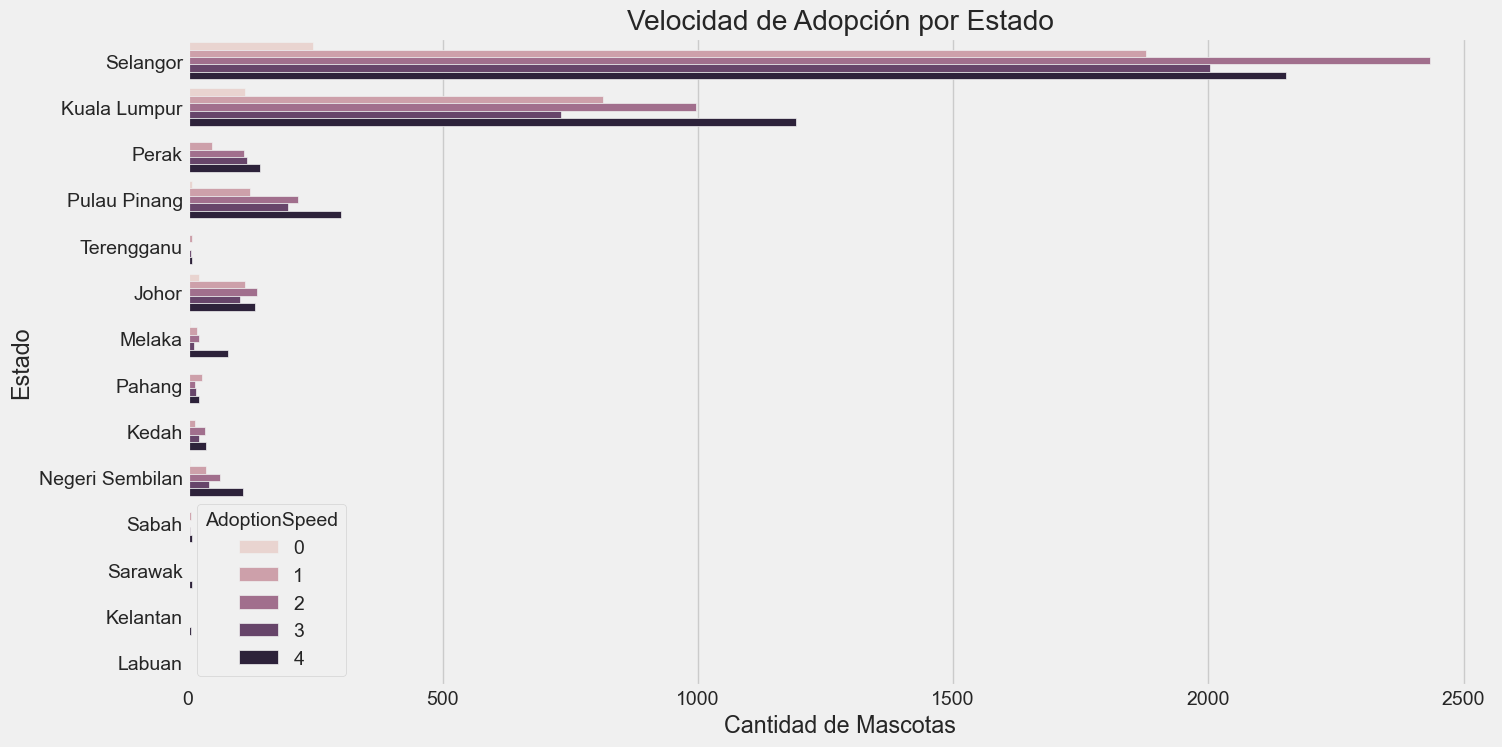

: 

: 

: 

: 

In [ ]:
plt.figure(figsize=(15, 8))
sns.countplot(y='State', hue='AdoptionSpeed', data=train_df)
plt.title('Velocidad de Adopción por Estado')
plt.xlabel('Cantidad de Mascotas')
plt.ylabel('Estado')
plt.show()

El estado de "Selangor" tiene, con mucho, la mayor cantidad de mascotas listadas, seguido de "Kuala Lumpur". La distribución de la velocidad de adopción parece ser similar en los estados con más mascotas.

# 8. Validación de Texto (Descripción) e Imágenes

Creamos una nueva columna que indica si la mascota tiene una descripción.

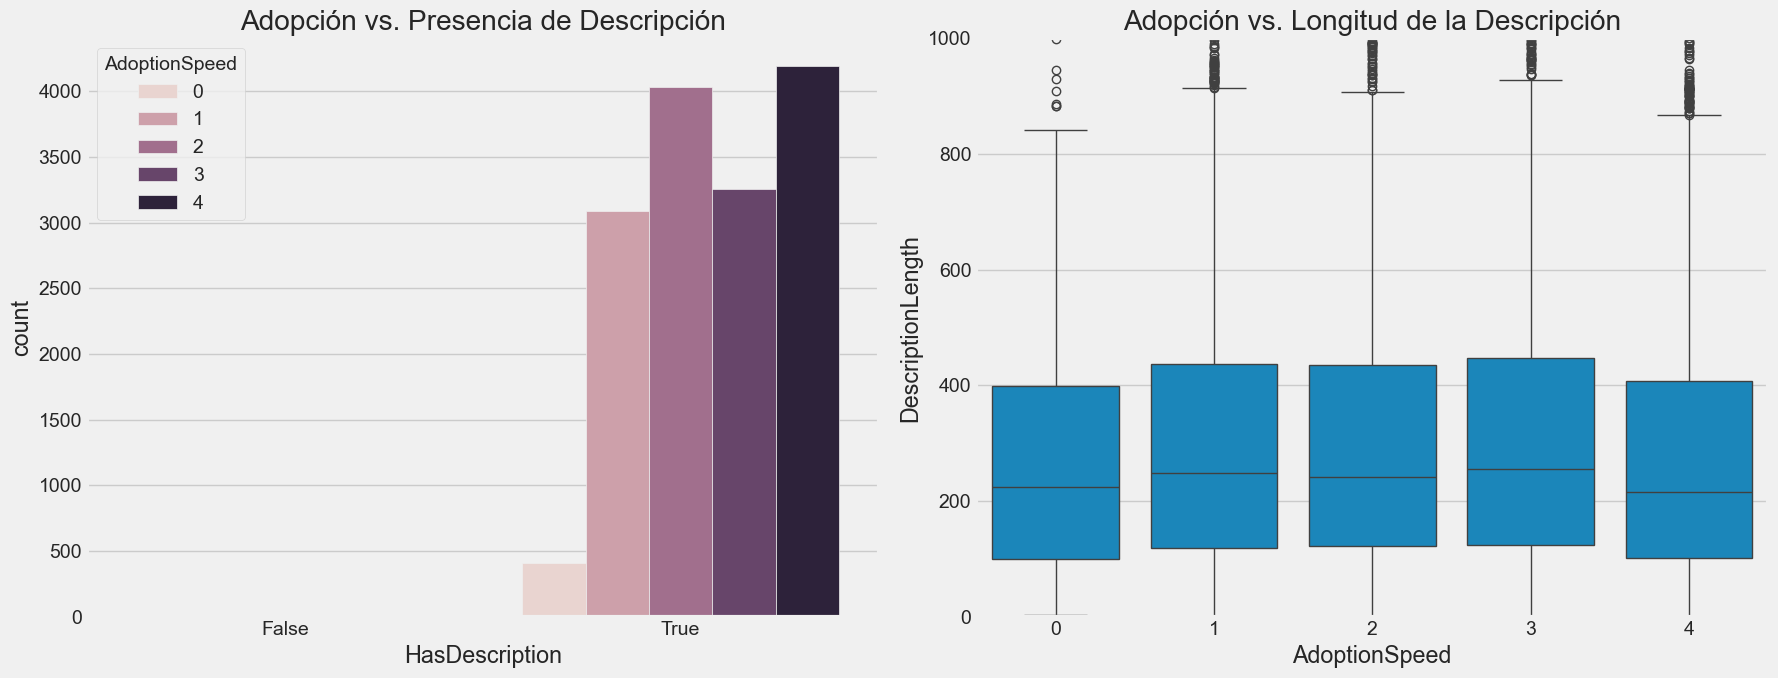

: 

: 

: 

: 

In [ ]:
train_df['HasDescription'] = train_df['Description'].notna()
train_df['DescriptionLength'] = train_df['Description'].str.len().fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.countplot(x='HasDescription', hue='AdoptionSpeed', data=train_df, ax=axes[0]).set_title('Adopción vs. Presencia de Descripción')
sns.boxplot(x='AdoptionSpeed', y='DescriptionLength', data=train_df, ax=axes[1]).set_title('Adopción vs. Longitud de la Descripción')
axes[1].set_ylim(0, 1000) # Limitamos el eje Y para una mejor visualización
fig.tight_layout()
plt.show()

Análisis:
 1. Presencia de Descripción: Las mascotas con descripción tienen una clara tendencia a ser adoptadas más rápido. La falta de descripción se correlaciona fuertemente con la categoría de adopción más lenta (4).

2. Longitud de la Descripción: Parece haber una tendencia a que descripciones más largas se asocien con adopciones más rápidas, aunque hay muchos valores atípicos. Una descripción detallada podría atraer más a los adoptantes.

Para validar las imágenes, necesitamos comprobar si existe un archivo de imagen para cada `PetID`.


Validando la existencia de imágenes...


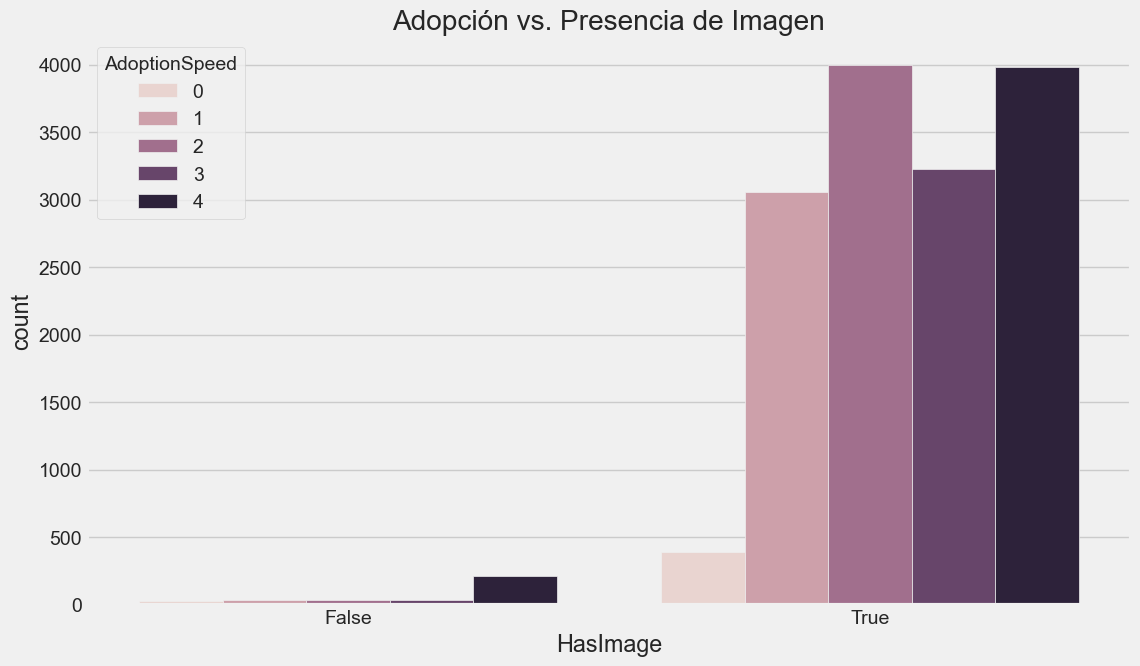

: 

: 

: 

: 

In [ ]:
IMAGE_PATH = os.path.join(BASE_PATH, "train_images")

# Esta operación puede tardar un poco
if os.path.exists(IMAGE_PATH):
    print("\nValidando la existencia de imágenes...")
    # Verificamos si al menos la primera imagen existe para cada mascota
    train_df['HasImage'] = train_df['PetID'].apply(lambda x: os.path.exists(os.path.join(IMAGE_PATH, f"{x}-1.jpg")))
    
    plt.figure(figsize=(12, 7))
    sns.countplot(x='HasImage', hue='AdoptionSpeed', data=train_df)
    plt.title('Adopción vs. Presencia de Imagen')
    plt.show()
    
   
else:
    print(f"\nLa carpeta de imágenes no se encontró en la ruta: {IMAGE_PATH}")
    print("Omitiendo el análisis de imágenes.")


Validando la existencia de imágenes...


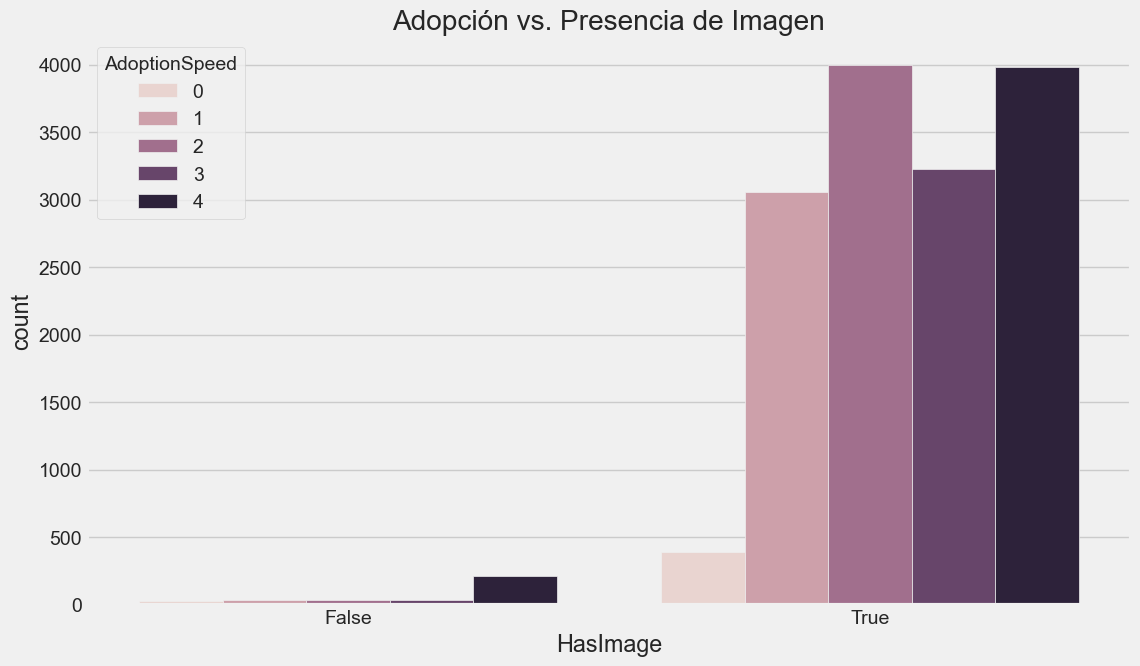

: 

: 

: 

: 

In [ ]:
IMAGE_PATH = os.path.join(BASE_PATH, "train_images")

# Esta operación puede tardar un poco
if os.path.exists(IMAGE_PATH):
    print("\nValidando la existencia de imágenes...")
    # Verificamos si al menos la primera imagen existe para cada mascota
    train_df['HasImage'] = train_df['PetID'].apply(lambda x: os.path.exists(os.path.join(IMAGE_PATH, f"{x}-1.jpg")))
    
    plt.figure(figsize=(12, 7))
    sns.countplot(x='HasImage', hue='AdoptionSpeed', data=train_df)
    plt.title('Adopción vs. Presencia de Imagen')
    plt.show()
    
    # **Análisis:** Si bien la gran mayoría de las mascotas tienen al menos una imagen, en el pequeño subconjunto que no la tiene, la velocidad de adopción es extremadamente lenta. Tener una imagen es un requisito fundamental.
else:
    print(f"\nLa carpeta de imágenes no se encontró en la ruta: {IMAGE_PATH}")
    print("Omitiendo el análisis de imágenes.")

Si bien la gran mayoría de las mascotas tienen al menos una imagen, en el pequeño subconjunto que no la tiene, la velocidad de adopción es extremadamente lenta. Tener una imagen es un requisito fundamental.

# 9. Resumen Final y Conclusiones

Tras realizar este análisis exploratorio, podemos extraer varias conclusiones clave sobre los factores que influyen en la velocidad de adopción de mascotas en PetFinder:
 
La Edad es el Factor más Determinante: Los cachorros y animales muy jóvenes son adoptados significativamente más rápido. La probabilidad de una adopción rápida disminuye drásticamente con cada mes que pasa.

*   La Preparación de la Mascota es Clave: Las mascotas que están esterilizadas, vacunadas y desparasitadas tienen una ventaja considerable. La esterilización, en particular, parece ser un fuerte indicador de una adopción más rápida.

*   La Presentación Importa (Texto e Imágenes):
    *   Tener una **imagen** es prácticamente un requisito; los anuncios sin ella apenas reciben atención.
    *   Una **descripción textual** no solo es necesaria, sino que su longitud también parece correlacionarse con una adopción más rápida. Una descripción detallada y atractiva puede marcar la diferencia.
 
 *   **La Tarifa no es un Impedimento:** Contrariamente a lo que se podría pensar, las mascotas gratuitas no son necesariamente las que se adoptan más rápido. De hecho, una tarifa modesta podría estar asociada con animales más "listos para adoptar", lo que acelera el proceso.
 
 *   **Factores Menos Influyentes:** Variables como el género o si es perro o gato no muestran diferencias tan marcadas como los puntos anteriores, aunque existen matices.

